# Лабораторна робота №3: Дисперсійний аналіз даних (ANOVA)

**Дисципліна:** Інтелектуальний аналіз даних (ІАД)
**Студент:** Багрій-Белз Андрій, група КН-2327б

### Мета роботи:
Засвоїти теоретичні основи та практичні навички застосування однофакторного (One-Way ANOVA) та двофакторного (Two-Way ANOVA) дисперсійного аналізу в Python з використанням бібліотек `statsmodels`, `pandas`, `scipy` та візуалізацією засобами `seaborn` і `matplotlib`.

## 1. Імпорт необхідних бібліотек та налаштування середовища

**Мета:** Підключити інструменти для маніпуляції даними (`pandas`), розрахунку лінійних моделей та ANOVA-таблиць (`statsmodels`), статистичних критеріїв (`scipy.stats`) та побудови графіків.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.factorplots import interaction_plot
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'font.sans-serif': ['DejaVu Sans', 'Arial'], 'font.family': 'sans-serif'})
print('Всі бібліотеки успішно імпортовано!')

Всі бібліотеки успішно імпортовано!


## 2. Однофакторний дисперсійний аналіз (One-Way ANOVA) — `Voice.txt`

**Мета тесту:** Дослідити взаємозв'язок між зростом співака (`Hei`) та типом голосу (`Factor`: Soprano, Alto, Tenor, Bass).
Перевірити гіпотезу, чи є знайдена залежність реальним впливом тембру на зріст, чи це наслідок статевого диморфізму (жінки в середньому нижчі за чоловіків).

### 2.1. Завантаження даних Voice.txt

**Опис кроку:** Завантажуємо набір даних `Voice.txt` за допомогою `pandas` з підтримкою роботи як локально, так і у Google Colab.

In [2]:
# Завантаження локально або завантаження при роботі в Colab
voice_file = 'Voice.txt' if os.path.exists('Voice.txt') else 'Lab_3/Voice.txt'
if not os.path.exists(voice_file):
    import gdown
    gdown.download('https://drive.google.com/uc?id=1zc-C6y8EyHlhAYtLZ4fhwq_baA6IBDSB', 'Voice.txt', quiet=False)
    voice_file = 'Voice.txt'

df_voice = pd.read_csv(voice_file, sep=r'\s+')
print('Загальний розмір вибірки:', df_voice.shape)
print('\nКількість спостережень по типах голосу:')
print(df_voice['Factor'].value_counts())
print('\nПерші рядки:')
print(df_voice.head())

Загальний розмір вибірки: (130, 2)

Кількість спостережень по типах голосу:
Factor
Soprano    36
Alto       36
Tenor      35
Bass       23
Name: count, dtype: int64

Перші рядки:
   Hei   Factor
0   64  Soprano
1   62  Soprano
2   66  Soprano
3   65  Soprano
4   60  Soprano


### 2.2. Повний однофакторний ANOVA для всіх співаків

**Опис тесту:** Моделюємо лінійну залежність `Hei ~ Factor`. Перевіряємо нульову гіпотезу $H_0$ про рівність середніх зростів у чотирьох голосових групах.

In [3]:
model_voice_all = ols('Hei ~ Factor', data=df_voice).fit()
anova_voice_all = anova_lm(model_voice_all)
print('Таблиця ANOVA для всіх співаків:')
print(anova_voice_all)

f_stat = anova_voice_all.loc['Factor', 'F']
p_val = anova_voice_all.loc['Factor', 'PR(>F)']
print(f'\nІнтерпретація: F = {f_stat:.2f}, p-value = {p_val:.4e}')
print('Висновок: Оскільки p < 0.05, нульова гіпотеза відхиляється; є високозначуща різниця середніх зростів між типами голосу.')

Таблиця ANOVA для всіх співаків:
             df       sum_sq     mean_sq          F        PR(>F)
Factor      3.0  1046.231343  348.743781  54.313546  1.334470e-22
Residual  126.0   809.037888    6.420936        NaN           NaN

Інтерпретація: F = 54.31, p-value = 1.3345e-22
Висновок: Оскільки p < 0.05, нульова гіпотеза відхиляється; є високозначуща різниця середніх зростів між типами голосу.


### 2.3. Перевірка факторного впливу окремо всередині статевих груп (Жінки та Чоловіки)

**Опис тесту:** Якщо фактор тембру дійсно зумовлює зріст, різниця має спостерігатися і між Soprano та Alto (жінки), а також між Tenor та Bass (чоловіки).

In [4]:
# Фільтрація жіночої підгрупи: Soprano vs Alto
df_women = df_voice[df_voice['Factor'].isin(['Soprano', 'Alto'])].copy()
model_women = ols('Hei ~ Factor', data=df_women).fit()
anova_women = anova_lm(model_women)
print('=== ANOVA для ЖІНОК (Soprano vs Alto) ===')
print(anova_women)
p_women = anova_women.loc['Factor', 'PR(>F)']
print(f'p-value для жінок = {p_women:.4f} (> 0.05) -> різниця статистично незначуща.')

# Фільтрація чоловічої підгрупи: Tenor vs Bass
df_men = df_voice[df_voice['Factor'].isin(['Tenor', 'Bass'])].copy()
model_men = ols('Hei ~ Factor', data=df_men).fit()
anova_men = anova_lm(model_men)
print('\n=== ANOVA для ЧОЛОВІКІВ (Tenor vs Bass) ===')
print(anova_men)
p_men = anova_men.loc['Factor', 'PR(>F)']
print(f'p-value для чоловіків = {p_men:.4f} (> 0.05) -> різниця статистично незначуща.')

print('\nКлючовий висновок: Вплив тембру голосу на зріст у повній вибірці є артефактом статевого диморфізму (жінки нижчі за чоловіків).')

=== ANOVA для ЖІНОК (Soprano vs Alto) ===
            df  sum_sq   mean_sq         F    PR(>F)
Factor     1.0     8.0  8.000000  1.437741  0.234549
Residual  70.0   389.5  5.564286       NaN       NaN
p-value для жінок = 0.2345 (> 0.05) -> різниця статистично незначуща.

=== ANOVA для ЧОЛОВІКІВ (Tenor vs Bass) ===
            df      sum_sq   mean_sq         F    PR(>F)
Factor     1.0    3.582801  3.582801  0.478233  0.492081
Residual  56.0  419.537888  7.491748       NaN       NaN
p-value для чоловіків = 0.4921 (> 0.05) -> різниця статистично незначуща.

Ключовий висновок: Вплив тембру голосу на зріст у повній вибірці є артефактом статевого диморфізму (жінки нижчі за чоловіків).


### 2.4. Візуалізація результатів Voice (Boxplot)

**Опис графіка:** Діаграма розмаху зросту за типами голосу з накладеними індивідуальними точками та позначенням p-значень для кожної статі.

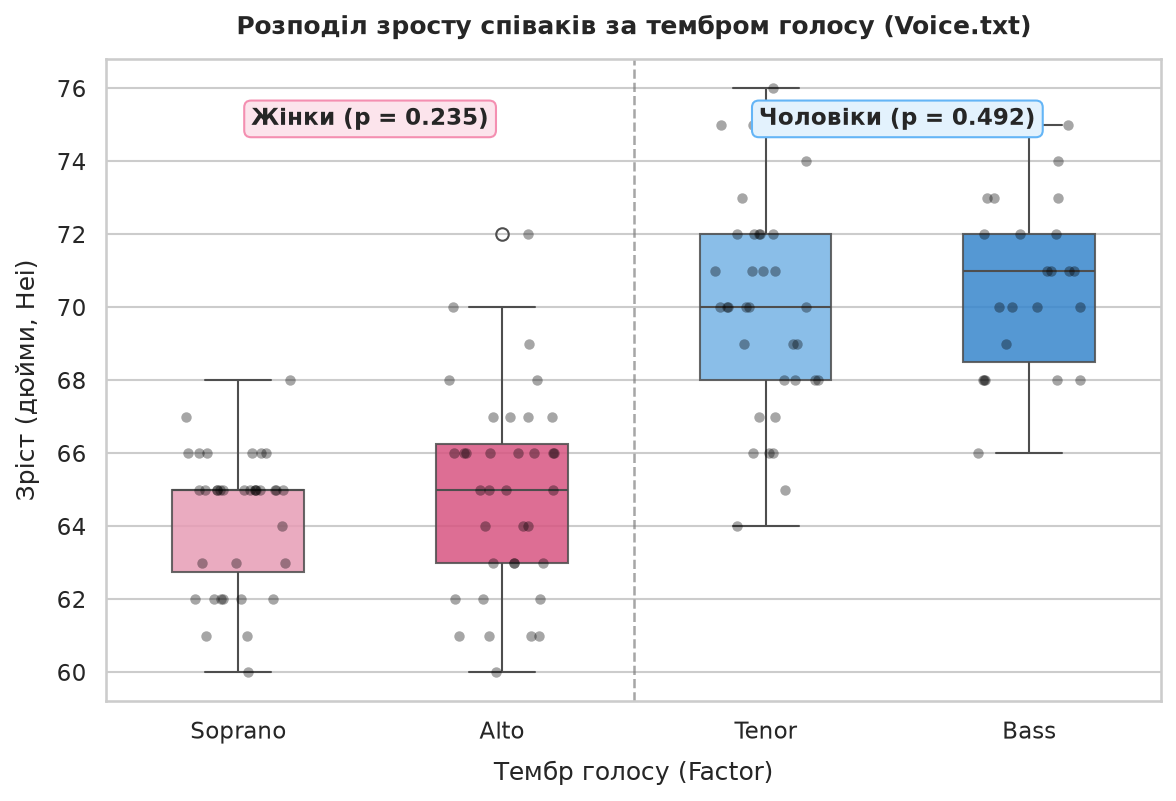

In [5]:
order_voice = ['Soprano', 'Alto', 'Tenor', 'Bass']
palette_voice = {'Soprano': '#f48fb1', 'Alto': '#ec407a', 'Tenor': '#64b5f6', 'Bass': '#1e88e5'}

fig, ax = plt.subplots(figsize=(8, 5.5), dpi=150)
sns.boxplot(x='Factor', y='Hei', hue='Factor', data=df_voice, order=order_voice, palette=palette_voice, width=0.5, boxprops=dict(alpha=0.85), legend=False, ax=ax)
sns.stripplot(x='Factor', y='Hei', data=df_voice, order=order_voice, color='black', alpha=0.35, jitter=0.2, size=5, ax=ax)
ax.set_title('Розподіл зросту співаків за тембром голосу (Voice.txt)', pad=12, fontweight='bold')
ax.set_xlabel('Тембр голосу (Factor)', labelpad=8)
ax.set_ylabel('Зріст (дюйми, Hei)', labelpad=8)
ax.axvline(1.5, color='grey', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(0.5, df_voice['Hei'].max() - 1, 'Жінки (p = 0.235)', horizontalalignment='center', fontsize=11, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc='#fce4ec', ec='#f48fb1'))
ax.text(2.5, df_voice['Hei'].max() - 1, 'Чоловіки (p = 0.492)', horizontalalignment='center', fontsize=11, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', fc='#e3f2fd', ec='#64b5f6'))
plt.tight_layout()
plt.show()

## 3. Двофакторний дисперсійний аналіз (Two-Way ANOVA) — `rat.txt`

**Мета тесту:** Дослідити вплив фактора середовища (`ENVIRNMNT`: Free vs Restricted), генетичної лінії щурів (`STRAIN`: Bright, Mixed, Dull) та їхньої міжфакторної взаємодії (`ENVIRNMNT:STRAIN`) на кількість помилок при проходженні лабіринту (`ERRORS`).

### 3.1. Завантаження даних rat.txt

**Опис кроку:** Зчитуємо дані експерименту над щурами.

In [6]:
rat_file = 'rat.txt' if os.path.exists('rat.txt') else 'Lab_3/rat.txt'
if not os.path.exists(rat_file):
    import gdown
    gdown.download('https://drive.google.com/uc?id=14qreu8glN6Yq9w1ECYYJy2BlpD_OAi0I', 'rat.txt', quiet=False)
    rat_file = 'rat.txt'

df_rat = pd.read_csv(rat_file, sep=r'\s+')
print('Розмірність вибірки:', df_rat.shape)
print('\nПерші рядки:')
print(df_rat.head())

Розмірність вибірки: (24, 3)

Перші рядки:
  ENVIRNMNT  ERRORS  STRAIN
0      Free      26  Bright
1      Free      14  Bright
2      Free      41  Bright
3      Free      16  Bright
4      Free      41   Mixed


### 3.2. Оцінка двофакторної моделі (Two-Way ANOVA Type II)

**Опис тесту:** Будуємо модель `ERRORS ~ C(ENVIRNMNT) + C(STRAIN) + C(ENVIRNMNT):C(STRAIN)` і формуємо ANOVA таблицю другого типу (`typ=2`).

In [7]:
model_rat = ols('ERRORS ~ C(ENVIRNMNT) + C(STRAIN) + C(ENVIRNMNT):C(STRAIN)', data=df_rat).fit()
anova_rat = anova_lm(model_rat, typ=2)
print('Двофакторна таблиця ANOVA (rat.txt):')
print(anova_rat)

p_env = anova_rat.loc['C(ENVIRNMNT)', 'PR(>F)']
p_strain = anova_rat.loc['C(STRAIN)', 'PR(>F)']
p_inter = anova_rat.loc['C(ENVIRNMNT):C(STRAIN)', 'PR(>F)']

print(f'\nВплив середовища: F = {anova_rat.loc["C(ENVIRNMNT)", "F"]:.3f}, p = {p_env:.4f} (< 0.05) -> статистично значущий')
print(f'Вплив генетичної лінії: F = {anova_rat.loc["C(STRAIN)", "F"]:.3f}, p = {p_strain:.4f} (< 0.05) -> статистично значущий')
print(f'Взаємодія факторів: F = {anova_rat.loc["C(ENVIRNMNT):C(STRAIN)", "F"]:.4f}, p = {p_inter:.4f} (> 0.05) -> ефект взаємодії відсутній (фактори адитивні)')

Двофакторна таблиця ANOVA (rat.txt):
                              sum_sq    df         F    PR(>F)
C(ENVIRNMNT)             5551.041667   1.0  5.822516  0.026705
C(STRAIN)                7939.750000   2.0  4.164023  0.032635
C(ENVIRNMNT):C(STRAIN)     16.083333   2.0  0.008435  0.991604
Residual                17160.750000  18.0       NaN       NaN

Вплив середовища: F = 5.823, p = 0.0267 (< 0.05) -> статистично значущий
Вплив генетичної лінії: F = 4.164, p = 0.0326 (< 0.05) -> статистично значущий
Взаємодія факторів: F = 0.0084, p = 0.9916 (> 0.05) -> ефект взаємодії відсутній (фактори адитивні)


### 3.3. Візуалізація взаємодії факторів (Interaction Plot)

**Опис графіка:** Графік середніх значень помилок для різних середовищ та ліній щурів. Паралельність ліній візуально підтверджує відсутність взаємодії між факторами.

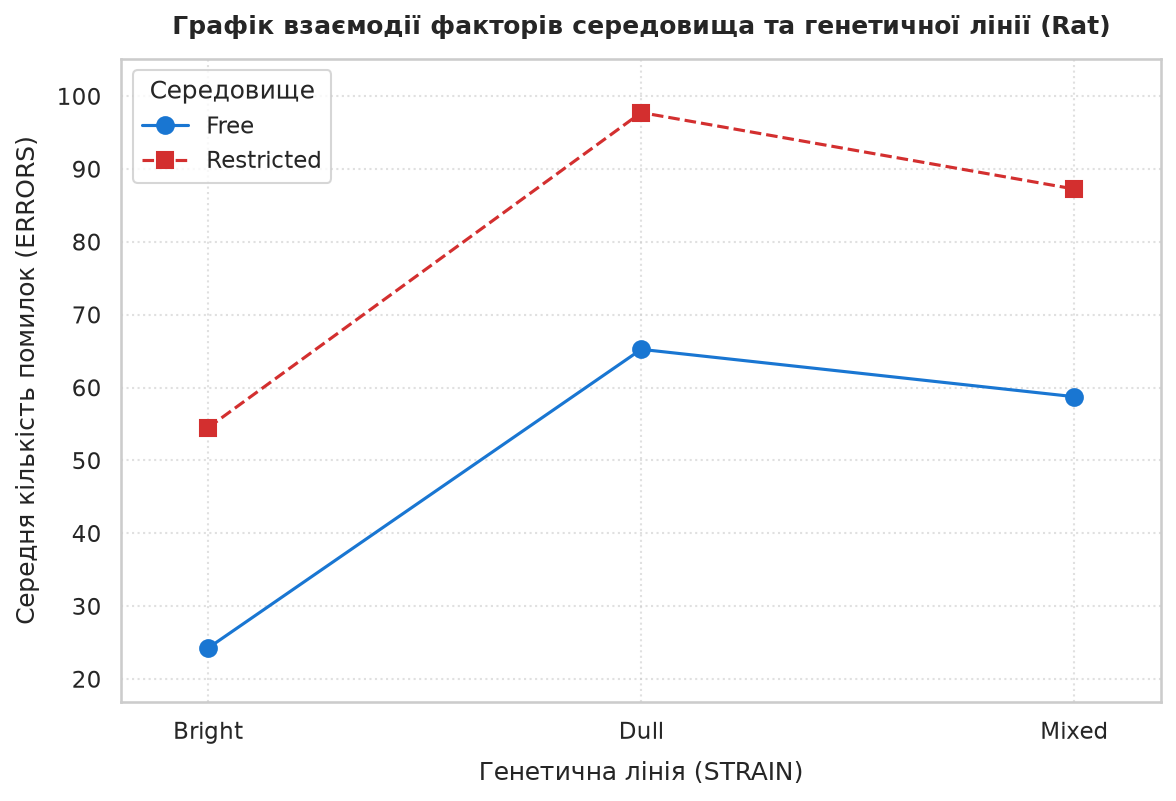

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=150)
interaction_plot(
    x=df_rat['STRAIN'],
    trace=df_rat['ENVIRNMNT'],
    response=df_rat['ERRORS'],
    colors=['#1976d2', '#d32f2f'],
    markers=['o', 's'],
    ms=8,
    linestyles=['-', '--'],
    ax=ax,
    legendtitle='Середовище'
)
ax.set_title('Графік взаємодії факторів середовища та генетичної лінії (Rat)', pad=12, fontweight='bold')
ax.set_xlabel('Генетична лінія (STRAIN)', labelpad=8)
ax.set_ylabel('Середня кількість помилок (ERRORS)', labelpad=8)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 3.4. Візуалізація розподілу помилок (Boxplot)

**Опис графіка:** Діаграма розмаху кількості помилок щурів за лінією та умовами середовища.

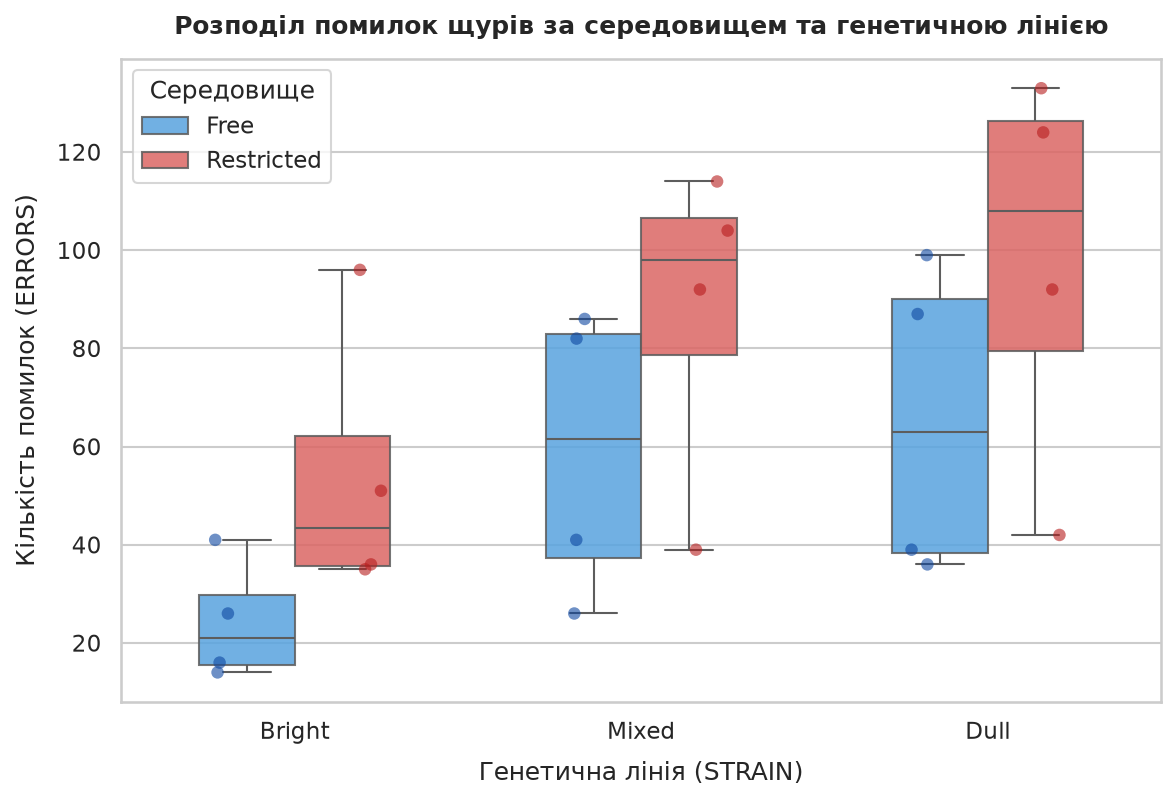

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=150)
sns.boxplot(
    x='STRAIN',
    y='ERRORS',
    hue='ENVIRNMNT',
    data=df_rat,
    palette={'Free': '#42a5f5', 'Restricted': '#ef5350'},
    width=0.55,
    boxprops=dict(alpha=0.85),
    ax=ax
)
sns.stripplot(
    x='STRAIN',
    y='ERRORS',
    hue='ENVIRNMNT',
    data=df_rat,
    dodge=True,
    palette={'Free': '#0d47a1', 'Restricted': '#b71c1c'},
    alpha=0.6,
    size=6,
    ax=ax
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Середовище')
ax.set_title('Розподіл помилок щурів за середовищем та генетичною лінією', pad=12, fontweight='bold')
ax.set_xlabel('Генетична лінія (STRAIN)', labelpad=8)
ax.set_ylabel('Кількість помилок (ERRORS)', labelpad=8)
plt.tight_layout()
plt.show()

## 4. Дисперсійний аналіз власного набору даних (`tips`)

**Мета тесту:** Дослідити вплив дня тижня (`day`: Thur, Fri, Sat, Sun) на суму загального рахунку клієнтів ресторану (`total_bill`). Перевірити передумови ANOVA (гомогенність дисперсій) та оцінити статистичну значущість різниці.

### 4.1. Завантаження даних та описова статистика

**Опис кроку:** Завантажуємо вбудований датасет `tips` бібліотеки `seaborn` та виводимо описові характеристики для кожного дня тижня.

In [10]:
df_tips = sns.load_dataset('tips')
print(f'Кількість спостережень: {len(df_tips)}')
print('\nОписова статистика total_bill по днях тижня:')
print(df_tips.groupby('day', observed=False)['total_bill'].describe())

Кількість спостережень: 244

Описова статистика total_bill по днях тижня:
      count       mean       std   min      25%    50%      75%    max
day                                                                   
Thur   62.0  17.682742  7.886170  7.51  12.4425  16.20  20.1550  43.11
Fri    19.0  17.151579  8.302660  5.75  12.0950  15.38  21.7500  40.17
Sat    87.0  20.441379  9.480419  3.07  13.9050  18.24  24.7400  50.81
Sun    76.0  21.410000  8.832122  7.25  14.9875  19.63  25.5975  48.17


### 4.2. Перевірка припущень та обчислення One-Way ANOVA

**Опис тесту:** 
1. Перевірка однорідності дисперсій тестом Левена (`scipy.stats.levene`).
2. Оцінка моделі `total_bill ~ C(day)` за допомогою дисперсійного аналізу.

In [11]:
# Перевірка гомогенності дисперсій (тест Левена)
groups_tips = [group['total_bill'].values for _, group in df_tips.groupby('day', observed=False)]
stat_levene, p_levene = stats.levene(*groups_tips)
print(f'Тест Левена: W = {stat_levene:.4f}, p = {p_levene:.4f}')
print('Оскільки p > 0.05, дисперсії між групами є однорідними (гомогенними), припущення ANOVA виконано.')

# Однофакторний ANOVA
model_tips = ols('total_bill ~ C(day)', data=df_tips).fit()
anova_tips = anova_lm(model_tips)
print('\nТаблиця ANOVA для набору tips:')
print(anova_tips)

f_tips = anova_tips.loc['C(day)', 'F']
p_tips = anova_tips.loc['C(day)', 'PR(>F)']
print(f'\nРезультат: F = {f_tips:.3f}, p-value = {p_tips:.4f}')
print('Оскільки p = 0.0425 < 0.05, день тижня має статистично значущий вплив на суму рахунку (у вихідні середній чек вищий).')

Тест Левена: W = 0.6654, p = 0.5741
Оскільки p > 0.05, дисперсії між групами є однорідними (гомогенними), припущення ANOVA виконано.

Таблиця ANOVA для набору tips:
             df        sum_sq     mean_sq         F    PR(>F)
C(day)      3.0    643.941362  214.647121  2.767479  0.042454
Residual  240.0  18614.522721   77.560511       NaN       NaN

Результат: F = 2.767, p-value = 0.0425
Оскільки p = 0.0425 < 0.05, день тижня має статистично значущий вплив на суму рахунку (у вихідні середній чек вищий).


### 4.3. Візуалізація розподілу рахунків (Boxplot)

**Опис графіка:** Діаграма розмаху суми рахунку по днях тижня з точковими спостереженнями та лінією групових середніх значень.

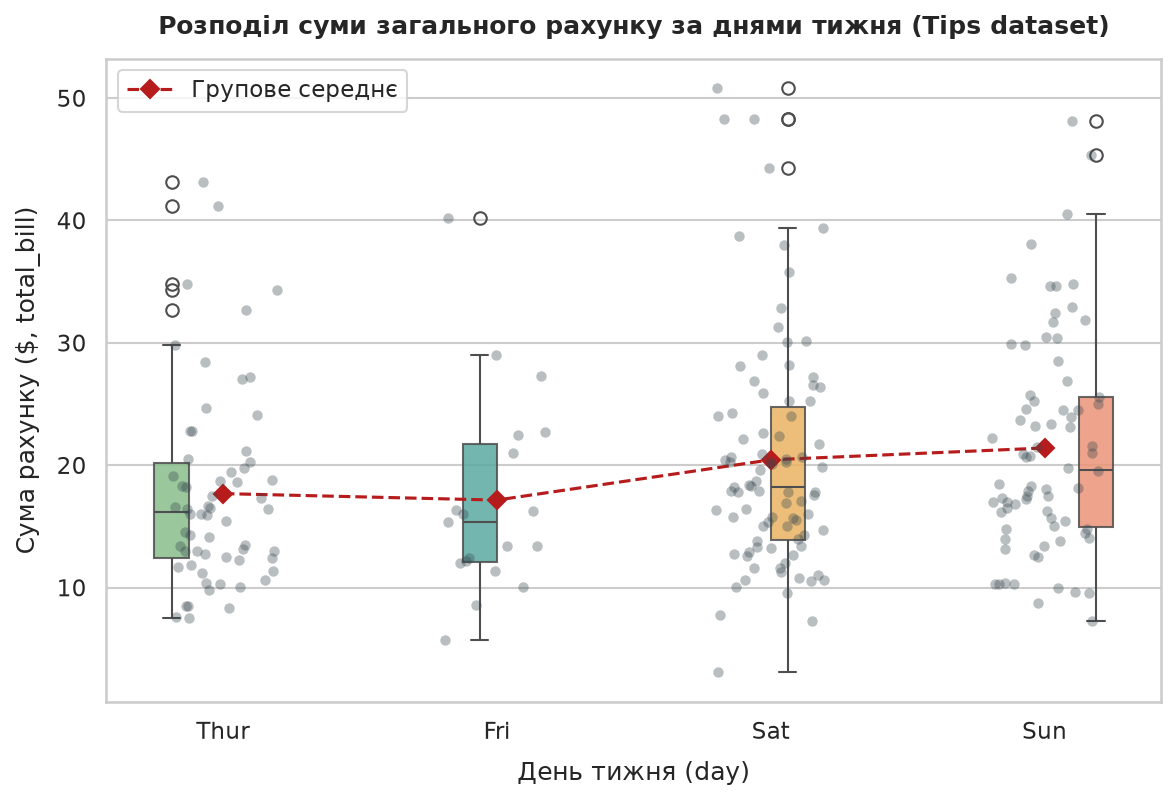

In [12]:
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
palette_tips = {'Thur': '#81c784', 'Fri': '#4db6ac', 'Sat': '#ffb74d', 'Sun': '#ff8a65'}

fig, ax = plt.subplots(figsize=(8, 5.5), dpi=150)
sns.boxplot(
    x='day',
    y='total_bill',
    hue='day',
    data=df_tips,
    order=day_order,
    palette=palette_tips,
    width=0.5,
    boxprops=dict(alpha=0.85),
    legend=False,
    ax=ax
)
sns.stripplot(
    x='day',
    y='total_bill',
    data=df_tips,
    order=day_order,
    color='#37474f',
    alpha=0.35,
    jitter=0.2,
    size=5,
    ax=ax
)
day_means = df_tips.groupby('day', observed=False)['total_bill'].mean().loc[day_order]
ax.plot(range(4), day_means, color='#b71c1c', marker='D', markersize=6, linestyle='--', linewidth=1.5, label='Групове середнє')
ax.set_title('Розподіл суми загального рахунку за днями тижня (Tips dataset)', pad=12, fontweight='bold')
ax.set_xlabel('День тижня (day)', labelpad=8)
ax.set_ylabel('Сума рахунку ($, total_bill)', labelpad=8)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 5. Підсумкові висновки

1. **Датасет Voice:** Однофакторний ANOVA для повної вибірки виявив формально значущий вплив тембру голосу на зріст ($p = 1.33 \times 10^{-22}$). Проте роздільний аналіз для жінок ($p = 0.235$) та чоловіків ($p = 0.492$) довів, що всередині кожної статі тембр голосу не має статистично значущого зв'язку зі зростом. Загальний ефект зумовлений виключно статевим диморфізмом.
2. **Датасет Rat:** Двофакторний ANOVA підтвердив значущий вплив умов середовища ($F = 5.823, p = 0.0267$) та генетичної лінії ($F = 4.164, p = 0.0326$) на кількість помилок щурів. Міжфакторна взаємодія відсутня ($F = 0.0084, p = 0.9916$), що означає адитивний характер дії факторів середовища та спадковості.
3. **Датасет Tips:** Дослідження впливу дня тижня на середній чек виявило статистично значущу різницю ($F = 2.767, p = 0.0425$) при підтвердженій однорідності групових дисперсій (тест Левена $p = 0.5741$). У вихідні дні спостерігається тенденція до вищих сум чеків порівняно з четвергом та п'ятницею.